# 💻 Predicción de Precios de Portátiles
### Competición Kaggle | Métrica: MAE (Mean Absolute Error)

**Flujo del notebook:**
1. Importar librerías y cargar datos
2. Exploración rápida (EDA)
3. Limpieza y feature engineering
4. Entrenamiento de varios modelos
5. Evaluación y comparación
6. Predicción sobre el conjunto de test


## 1. Importar librerías y cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesado
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# Cargamos los datos
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Train: {train.shape[0]} filas, {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]} filas, {test.shape[1]} columnas")
train.head()

Train: 912 filas, 14 columnas
Test:  391 filas, 13 columnas


,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,697,705,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,435,442,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,735,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,864,875,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,1176,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


## 2. Exploración rápida (EDA)

In [3]:
# Tipos de datos y nulos
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   laptop_ID         912 non-null    int64  
 2   Company           912 non-null    str    
 3   Product           912 non-null    str    
 4   TypeName          912 non-null    str    
 5   Inches            912 non-null    float64
 6   ScreenResolution  912 non-null    str    
 7   Cpu               912 non-null    str    
 8   Ram               912 non-null    str    
 9   Memory            912 non-null    str    
 10  Gpu               912 non-null    str    
 11  OpSys             912 non-null    str    
 12  Weight            912 non-null    str    
 13  Price_euros       912 non-null    float64
dtypes: float64(2), int64(2), str(10)
memory usage: 99.9 KB


In [4]:
# Estadísticas básicas de la variable objetivo
print("📊 Estadísticas de Price_euros:")
print(train['Price_euros'].describe().round(2))

📊 Estadísticas de Price_euros:
count     912.00
mean     1126.92
std       696.09
min       174.00
25%       589.00
50%       952.00
75%      1499.00
max      4899.00
Name: Price_euros, dtype: float64


## 3. Limpieza y Feature Engineering

Aquí transformamos las columnas que vienen como texto en números que los modelos puedan entender.


In [5]:
def limpiar_datos(df):
    """Aplica todas las transformaciones al dataframe recibido."""
    df = df.copy()

    # --- RAM: '8GB' -> 8 ---
    df['Ram_GB'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)

    # --- Weight: '1.5kg' -> 1.5 ---
    df['Weight_kg'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

    # --- CPU: extraemos marca y velocidad ---
    df['Cpu_brand'] = df['Cpu'].apply(lambda x: x.split()[0])  # Intel / AMD / Samsung...
    # Buscamos el número de GHz (ej. '2.7GHz' -> 2.7)
    df['Cpu_GHz'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz').astype(float)

    # --- GPU: extraemos la marca ---
    df['Gpu_brand'] = df['Gpu'].apply(lambda x: x.split()[0])  # Intel / Nvidia / AMD

    # --- Resolución de pantalla: extraemos píxeles totales ---
    # Buscamos patrones tipo '1920x1080'
    res = df['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})')
    df['Screen_w'] = res[0].astype(float)
    df['Screen_h'] = res[1].astype(float)
    df['Screen_pixels'] = df['Screen_w'] * df['Screen_h']

    # --- Pantalla táctil: si la descripción contiene 'Touchscreen' ---
    df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen').astype(int)

    # --- Memoria: capacidad total en GB ---
    # Simplificamos: extraemos el primer número mencionado
    df['Storage_GB'] = df['Memory'].str.extract(r'(\d+\.?\d*)').astype(float)
    # Si viene en TB (ej. '1TB') lo pasamos a GB
    es_tb = df['Memory'].str.contains('TB') & ~df['Memory'].str.contains('GB')
    df.loc[es_tb, 'Storage_GB'] = df.loc[es_tb, 'Storage_GB'] * 1000

    return df

# Aplicamos a train y test
train_clean = limpiar_datos(train)
test_clean  = limpiar_datos(test)

print("✅ Limpieza aplicada")
print("\nNuevas columnas creadas:")
nuevas = ['Ram_GB','Weight_kg','Cpu_brand','Cpu_GHz','Gpu_brand',
          'Screen_pixels','Touchscreen','Storage_GB']
print(train_clean[nuevas].head())

✅ Limpieza aplicada

Nuevas columnas creadas:
   Ram_GB  Weight_kg Cpu_brand  Cpu_GHz Gpu_brand  Screen_pixels  Touchscreen  \
0       4       1.20     Intel      0.9     Intel      2073600.0            1   
1       8       3.20       AMD      3.2       AMD      2073600.0            0   
2       4       1.85     Intel      2.7     Intel      2073600.0            0   
3      16       1.29     Intel      2.5     Intel      5760000.0            1   
4       4       2.32     Intel      2.5     Intel      2073600.0            0   

   Storage_GB  
0        64.0  
1       256.0  
2      1000.0  
3       512.0  
4      1000.0  


In [6]:
# Seleccionamos las columnas que usaremos como features
features_cat = ['Company', 'TypeName', 'OpSys', 'Cpu_brand', 'Gpu_brand']
features_num = ['Inches', 'Ram_GB', 'Weight_kg', 'Cpu_GHz',
                'Screen_pixels', 'Touchscreen', 'Storage_GB']

# Codificamos las columnas categóricas con LabelEncoder
# (convierte texto a números: 'Asus'->0, 'Dell'->1, etc.)
le_dict = {}  # guardamos los encoders para usarlos también en test

train_model = train_clean.copy()
test_model  = test_clean.copy()

for col in features_cat:
    le = LabelEncoder()
    # Combinamos train y test para que el encoder vea todas las categorías
    all_vals = pd.concat([train_clean[col], test_clean[col]], axis=0)
    le.fit(all_vals)
    train_model[col] = le.transform(train_clean[col])
    test_model[col]  = le.transform(test_clean[col])
    le_dict[col] = le

all_features = features_cat + features_num

X = train_model[all_features]
y = train_model['Price_euros']
X_test_final = test_model[all_features]

print(f"✅ Features preparadas: {X.shape[1]} columnas")
print(f"   Filas en train: {X.shape[0]} | Filas en test: {X_test_final.shape[0]}")

✅ Features preparadas: 12 columnas
   Filas en train: 912 | Filas en test: 391


## 4. Entrenamiento de modelos

Dividimos el train en **80% entrenamiento / 20% validación** para poder medir el MAE antes de enviar las predicciones al test real.

Probamos 4 modelos de menor a mayor complejidad:
- **Regresión Lineal**: modelo base, sencillo
- **Árbol de Decisión**: aprende reglas si/no
- **Random Forest**: muchos árboles juntos (más robusto)
- **Gradient Boosting**: árboles que aprenden de los errores anteriores (suele ser el mejor)


In [7]:
# Partición train / validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train:      {X_train.shape[0]} filas")
print(f"Validación: {X_val.shape[0]} filas")

Train:      729 filas
Validación: 183 filas


In [8]:
# Definimos los modelos a comparar
modelos = {
    'Regresión Lineal':    LinearRegression(),
    'Árbol de Decisión':   DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                      max_depth=5, random_state=42),
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred_val = modelo.predict(X_val)

    mae  = mean_absolute_error(y_val, pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred_val))
    r2   = r2_score(y_val, pred_val)

    resultados[nombre] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"{nombre:<25}  MAE={mae:>7.1f}€   RMSE={rmse:>7.1f}€   R²={r2:.3f}")

Regresión Lineal           MAE=  307.3€   RMSE=  406.3€   R²=0.633
Árbol de Decisión          MAE=  248.8€   RMSE=  373.9€   R²=0.689
Random Forest              MAE=  191.0€   RMSE=  282.5€   R²=0.822
Gradient Boosting          MAE=  173.7€   RMSE=  255.4€   R²=0.855


## 5. Comparación visual de modelos

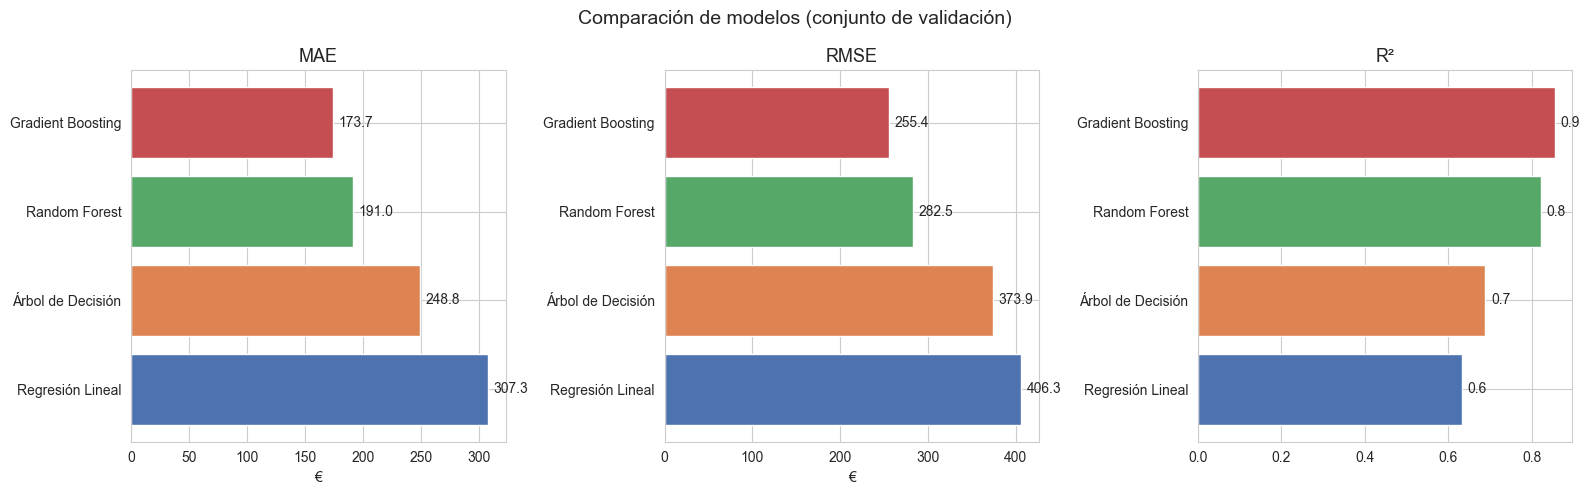


📌 El modelo con menor MAE es el mejor para esta competición.


In [9]:
df_res = pd.DataFrame(resultados).T.reset_index()
df_res.columns = ['Modelo', 'MAE', 'RMSE', 'R²']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores = ['#4c72b0','#dd8452','#55a868','#c44e52']

for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.barh(df_res['Modelo'], df_res[metrica], color=colores)
    ax.set_title(metrica, fontsize=13)
    ax.bar_label(bars, fmt='%.1f', padding=4)
    if metrica in ['MAE','RMSE']:
        ax.set_xlabel('€')

plt.suptitle('Comparación de modelos (conjunto de validación)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📌 El modelo con menor MAE es el mejor para esta competición.")

🏆 Mejor modelo: Gradient Boosting  (MAE = 173.7 €)


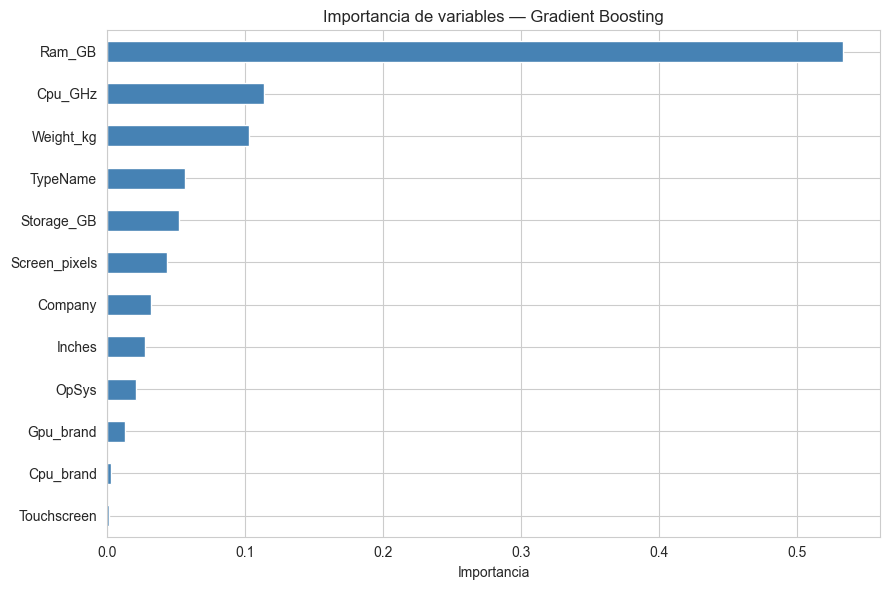

In [10]:
# Importancia de variables del mejor modelo (Random Forest / Gradient Boosting)
mejor_nombre = min(resultados, key=lambda k: resultados[k]['MAE'])
mejor_modelo  = modelos[mejor_nombre]

print(f"🏆 Mejor modelo: {mejor_nombre}  (MAE = {resultados[mejor_nombre]['MAE']:.1f} €)")

if hasattr(mejor_modelo, 'feature_importances_'):
    imp = pd.Series(mejor_modelo.feature_importances_, index=all_features)
    imp = imp.sort_values(ascending=True)

    plt.figure(figsize=(9, 6))
    imp.plot(kind='barh', color='steelblue')
    plt.title(f'Importancia de variables — {mejor_nombre}')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.show()

## 6. Predicción sobre el test y generación del archivo de envío

In [11]:
# Re-entrenamos el mejor modelo con TODO el train (no solo el 80%)
mejor_modelo.fit(X, y)
predicciones_test = mejor_modelo.predict(X_test_final)

# Creamos el archivo de submission con el formato que pide Kaggle: id + Price_euros
submission = pd.DataFrame({
    'id': test['id'],
    'Price_euros': predicciones_test.round(2)
})

submission.to_csv('submission.csv', index=False)
print("✅ submission.csv guardado correctamente")
print(f"   Filas: {len(submission)}")
submission.head(10)

✅ submission.csv guardado correctamente
   Filas: 391


,id,Price_euros
0,824,1924.02
1,101,453.62
2,1157,1904.24
3,940,1399.27
4,853,1455.24
5,650,2464.06
6,317,261.36
7,217,903.66
8,489,1814.61
9,1245,1667.66


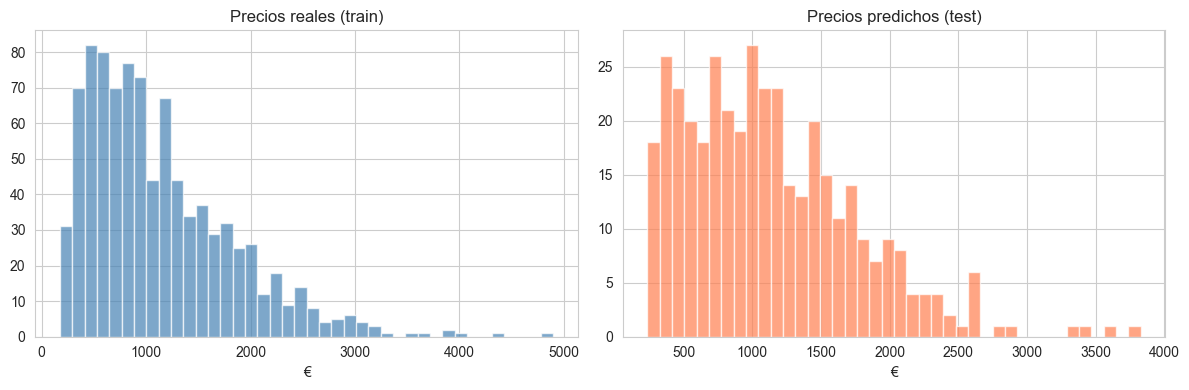


🎉 ¡Todo listo! Sube submission.csv a Kaggle.


In [12]:
# Distribución de las predicciones vs precios reales en train
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=40, alpha=0.7, color='steelblue', label='Train (real)')
plt.title('Precios reales (train)')
plt.xlabel('€')

plt.subplot(1, 2, 2)
plt.hist(predicciones_test, bins=40, alpha=0.7, color='coral', label='Test (predicho)')
plt.title('Precios predichos (test)')
plt.xlabel('€')

plt.tight_layout()
plt.show()
print("\n🎉 ¡Todo listo! Sube submission.csv a Kaggle.")